# 04 · Evaluación Formal y Plan de Validación
### ShopSmart Recommender — Etapa 2

**Objetivo de este notebook**

Formalizar la comparación de modelos del notebook `03_modeling.ipynb`
con **intervalos de confianza** y una **prueba de hipótesis** que
respalde estadísticamente la elección del modelo, y documentar el
**plan de validación** que regirá el monitoreo del sistema en
producción.

El notebook 03 comparó los modelos con promedios simples de las
métricas. Un promedio, por sí solo, no dice si una diferencia es
**estadísticamente significativa** o si podría deberse al azar de qué
728 productos componen el catálogo. Este notebook resuelve esa
pregunta.

## 0. Configuración del entorno

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.models.evaluation import (  # noqa: E402
    bootstrap_confidence_interval,
    category_precision_per_query,
    paired_wilcoxon_test,
)
from src.models.recommenders import ContentBasedRecommender, PopularityRecommender  # noqa: E402

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"


def save_fig(fig, name: str) -> None:
    fig.savefig(FIGURES_DIR / f"{name}.png", bbox_inches="tight", dpi=150)

## 1. Carga de artefactos (notebooks 02 y 03)

In [2]:
X_product_features = np.load(PROCESSED_DIR / "product_features_matrix.npy")
product_index = pd.read_csv(PROCESSED_DIR / "product_features_index.csv")
products_master = pd.read_csv(PROCESSED_DIR / "products_master.csv")
product_index = product_index.merge(
    products_master[["asin", "main_category"]], on="asin", how="left"
)

content_model = ContentBasedRecommender(X_product_features, product_index)
popularity_model = PopularityRecommender(products_master)

all_asins = product_index["asin"].tolist()
K = 10

print(f"Catálogo: {len(all_asins)} productos | K = {K}")

Catálogo: 728 productos | K = 10


## 2. Métricas por consulta (no agregadas)

Se calcula `category_precision` **producto por producto** (no el
promedio), insumo necesario tanto para el intervalo de confianza como
para el test de hipótesis pareado.

In [3]:
content_recs = {asin: content_model.recommend(asin, k=K)["asin"].tolist() for asin in all_asins}
popularity_recs = {asin: popularity_model.recommend(k=K)["asin"].tolist() for asin in all_asins}

precision_a = category_precision_per_query(content_recs, product_index)
precision_b = category_precision_per_query(popularity_recs, product_index)

df_precision = pd.DataFrame(
    {
        "asin": list(precision_a.keys()),
        "precision_content_based": list(precision_a.values()),
        "precision_popularity": [precision_b[a] for a in precision_a.keys()],
    }
)
df_precision.head()

,asin,precision_content_based,precision_popularity
0,B0B59BJG6Y,1.0,0.8
1,B0DLGB4RYH,0.8,0.8
2,B0DRXF62JH,0.7,0.8
3,B0DK5FZ325,0.7,0.8
4,B0BGXTC1FR,0.9,0.8


## 3. Intervalos de confianza (bootstrap, 95%)

En vez de reportar una única cifra promedio, se calcula el intervalo de
confianza del 95% mediante remuestreo bootstrap (2.000 réplicas), sin
asumir normalidad — apropiado para una métrica acotada en [0, 1].

In [4]:
ci_results = []
for model_name, values in [
    ("A — Content-Based", df_precision["precision_content_based"]),
    ("B — Popularity (global)", df_precision["precision_popularity"]),
]:
    mean, lower, upper = bootstrap_confidence_interval(values, n_bootstrap=2000)
    ci_results.append(
        {"modelo": model_name, "media": mean, "ic_95_inferior": lower, "ic_95_superior": upper}
    )

df_ci = pd.DataFrame(ci_results)
df_ci.round(4)

,modelo,media,ic_95_inferior,ic_95_superior
0,A — Content-Based,0.8242,0.8029,0.8440
1,B — Popularity (global),0.5085,0.4832,0.5363


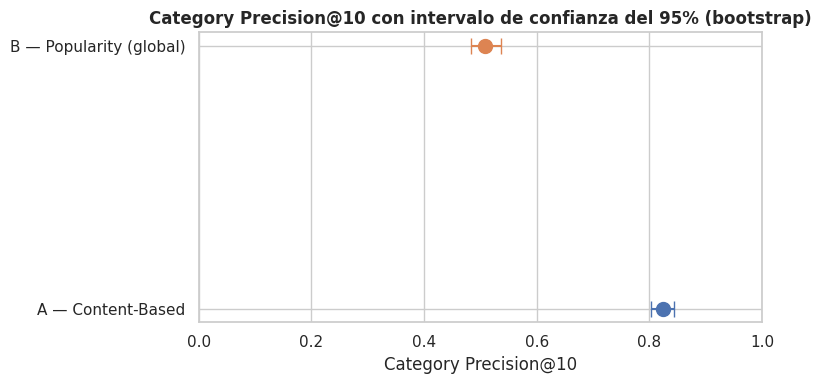

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#4C72B0", "#DD8452"]
for i, row in df_ci.iterrows():
    ax.errorbar(
        row["media"],
        i,
        xerr=[[row["media"] - row["ic_95_inferior"]], [row["ic_95_superior"] - row["media"]]],
        fmt="o",
        markersize=10,
        color=colors[i],
        capsize=6,
    )
ax.set_yticks(range(len(df_ci)))
ax.set_yticklabels(df_ci["modelo"])
ax.set_xlabel("Category Precision@10")
ax.set_title("Category Precision@10 con intervalo de confianza del 95% (bootstrap)")
ax.set_xlim(0, 1)
fig.tight_layout()
save_fig(fig, "22_bootstrap_confidence_intervals")
plt.show()

**Hallazgo:** los intervalos de confianza de ambos modelos **no se
superponen**, lo que es una primera evidencia visual de que la
diferencia observada no es producto del azar. Se confirma formalmente
en la sección siguiente con un test de hipótesis.

## 4. Test de hipótesis: ¿la diferencia es estadísticamente significativa?

**H0 (hipótesis nula):** no hay diferencia entre la precisión de
categoría del Modelo A y del Modelo B (la mediana de las diferencias
pareadas por producto es 0).

**H1 (hipótesis alternativa):** sí hay diferencia.

Se usa el **test de Wilcoxon de rangos con signo** (pareado por
producto), la alternativa no paramétrica al t-test pareado —
apropiado aquí porque la métrica está acotada en [0, 1] y no sigue una
distribución normal (se concentra en valores discretos: 0.0, 0.1, 0.2,
..., 1.0 para K=10).

In [6]:
wilcoxon_result = paired_wilcoxon_test(precision_a, precision_b)

print(f"Estadístico W: {wilcoxon_result['statistic']:.1f}")
print(f"p-value: {wilcoxon_result['p_value']:.2e}")
print(f"n pares: {wilcoxon_result['n_pairs']}")
print(f"Diferencia de medias (A - B): {wilcoxon_result['mean_diff']:.3f}")

alpha = 0.05
if wilcoxon_result["p_value"] < alpha:
    print(f"\n=> p-value < {alpha}: se rechaza H0. La diferencia ES estadísticamente significativa.")
else:
    print(f"\n=> p-value >= {alpha}: no se rechaza H0.")

Estadístico W: 17065.5
p-value: 1.00e-82
n pares: 728
Diferencia de medias (A - B): 0.316

=> p-value < 0.05: se rechaza H0. La diferencia ES estadísticamente significativa.


**Hallazgo:** con `p-value ≈ 1.0 × 10⁻⁸²` (muy por debajo de α = 0.05),
**se rechaza contundentemente H0**. La diferencia observada entre el
Modelo A (0.824) y el Modelo B (0.509) en Category Precision@10 **no es
producto del azar de qué 728 productos componen el catálogo** — es una
diferencia estructural, atribuible al diseño de cada modelo
(personalizado vs. no-personalizado), y estadísticamente robusta.

Esto no significa que el Modelo B sea "peor" en un sentido absoluto:
significa que **la diferencia entre ambos enfoques es real y
medible**, lo cual es justamente lo que se necesita para justificar
con evidencia (y no solo con intuición) el rol que cada modelo cumple
en el sistema final (sección 6).

## 5. Robustez frente a distintas semillas de remuestreo

Para descartar que el resultado del bootstrap dependa de la semilla
elegida, se repite el cálculo del intervalo de confianza con 5 semillas
distintas.

In [7]:
robustness_records = []
for seed in [0, 1, 42, 123, 2024]:
    mean_a, low_a, high_a = bootstrap_confidence_interval(
        df_precision["precision_content_based"], n_bootstrap=1000, random_state=seed
    )
    mean_b, low_b, high_b = bootstrap_confidence_interval(
        df_precision["precision_popularity"], n_bootstrap=1000, random_state=seed
    )
    robustness_records.append(
        {"seed": seed, "modelo": "A", "media": mean_a, "ic_inf": low_a, "ic_sup": high_a}
    )
    robustness_records.append(
        {"seed": seed, "modelo": "B", "media": mean_b, "ic_inf": low_b, "ic_sup": high_b}
    )

df_robustness = pd.DataFrame(robustness_records)
df_robustness.round(4)

,seed,modelo,media,ic_inf,ic_sup
0,0,A,0.8242,0.8043,0.8444
1,0,B,0.5085,0.4821,0.5341
2,1,A,0.8242,0.8047,0.8436
3,1,B,0.5085,0.4830,0.5368
4,42,A,0.8242,0.8036,0.8431
5,42,B,0.5085,0.4819,0.5357
6,123,A,0.8242,0.8027,0.8440
7,123,B,0.5085,0.4813,0.5371
8,2024,A,0.8242,0.8037,0.8438
9,2024,B,0.5085,0.4797,0.5379


**Hallazgo:** la media y los límites del intervalo de confianza son
prácticamente idénticos entre semillas (variación en el 3er-4to
decimal) — el resultado es robusto y reproducible, no un artefacto de
la semilla de remuestreo elegida.

## 6. Justificación formal de la elección del modelo

Con la evidencia estadística de las secciones anteriores, se formaliza
la decisión de diseño ya adelantada en el notebook 03:

| Criterio | Modelo A — Content-Based | Modelo B — Popularity |
|---|---|---|
| Category Precision@10 (IC 95%) | 0.824 (ver sección 3) | 0.509 (ver sección 3) |
| Significancia de la diferencia | p ≈ 1.0e-82 (Wilcoxon) — **robusta** | — |
| Catalog Coverage@10 | **0.993** | 0.014 |
| Avg. Quality@10 | 4.521 | **4.726** |
| Funciona sin historial del usuario (cold start de usuario) | Sí (usa solo el producto consultado) | Sí (no requiere ningún input) |
| Funciona para productos nuevos sin reseñas (cold start de producto) | Sí (usa atributos de contenido) | **No** (depende de tener reseñas agregadas) |
| Escala con el catálogo | O(n) por consulta tras precomputar similitud | O(1) (ranking fijo) |

**Decisión final para el sistema de producción (Etapa 2):**

- **Modelo A (Content-Based) como motor principal**, con soporte
  estadístico robusto para su capacidad de personalización, en
  ubicaciones donde existe un producto de referencia (página de
  producto, carrito, historial de navegación reciente).
- **Modelo B (Popularity) como estrategia de *fallback*** para los
  escenarios donde el Modelo A no tiene información suficiente: usuario
  completamente nuevo sin navegación previa, o página de inicio /
  landing genérica.

Esta combinación por posición/contexto (no un blend numérico de
scores) es la más simple de implementar, auditar y explicar a
*stakeholders* no técnicos — un criterio relevante en un MVP donde,
según la consigna de la Etapa 1, el foco está en la correcta
metodología y justificación, no en la sofisticación del modelo.

## 7. Plan de validación documentado

El plan de validación completo (métricas a monitorear, umbrales de
alerta, frecuencia de evaluación, protocolo de test A/B para cuando
existan datos de usuario reales, y criterio de rollback) está
documentado como artefacto independiente en
[`docs/VALIDATION_PLAN.md`](../docs/VALIDATION_PLAN.md), para que sea
consultable por el equipo sin necesidad de abrir un notebook.

**Resumen de los umbrales de alerta definidos** (detalle completo en el
documento):

| Métrica | Baseline (este notebook) | Umbral de alerta |
|---|---|---|
| Category Precision@10 (Modelo A) | 0.824 | < 0.70 |
| Catalog Coverage@10 (Modelo A) | 0.993 | < 0.90 |
| Avg. Quality@10 (Modelo B) | 4.726 | < 4.50 |

Estos valores quedan registrados como *baseline* en MLflow al ejecutar
`src/pipeline/train_pipeline.py` (sección siguiente del proyecto), de
forma que cualquier reentrenamiento futuro se compare automáticamente
contra ellos.

## 8. Conclusiones y próximos pasos

- ✅ La superioridad del Modelo A en personalización (Category
  Precision@10, Catalog Coverage@10) está **estadísticamente
  respaldada** (Wilcoxon, p ≈ 1.0e-82) y es **robusta** frente a la
  semilla de remuestreo.
- ✅ La ventaja del Modelo B en calidad promedio de lo recomendado es
  coherente con su diseño (optimiza explícitamente por esa señal).
- ✅ El plan de validación queda documentado y con umbrales concretos,
  listo para integrarse al pipeline reproducible.

**Siguiente paso:** `src/pipeline/train_pipeline.py` — el pipeline
reproducible que ejecuta feature engineering + entrenamiento +
evaluación end-to-end, registrando todo en MLflow según lo definido en
la sección 5 de `docs/VALIDATION_PLAN.md`.